In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

# Data Loading
test_lgbm   = pd.read_csv('data/processed/test_lgbm.csv')
test_neural = pd.read_csv('data/processed/test_neural.csv')

with open('data/processed/feat_cols_lgbm.txt') as f:
    feat_cols_lgbm = f.read().splitlines()
with open('data/processed/feat_cols_neural.txt') as f:
    feat_cols_neural = f.read().splitlines()

# LightGBM models
model_pw = lgb.Booster(model_file='models/lgbm_pointwise.txt')
model_lm = lgb.Booster(model_file='models/lgbm_lambdamart.txt')

print(f'Test set: {len(test_lgbm):,} rows | {test_lgbm["qid"].nunique():,} queries')

Device: mps
Test set: 241,521 rows | 2,000 queries


### Loading Neural Models

In [2]:
# CNN Ranker — fully-connected architecture
class CNNRanker(nn.Module):
    def __init__(self, n_features, dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),         nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32),          nn.ReLU(), nn.Dropout(dropout * 0.5),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        if x.dim() == 3:
            x = x.squeeze(1)
        return self.network(x).squeeze(-1)

# LSTM Ranker
class LSTMRanker(nn.Module):
    def __init__(self, n_features=64, hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout / 2)
        )
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, n_layers, batch_first=True,
                            bidirectional=True, dropout=dropout if n_layers > 1 else 0.0)
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(),
            nn.Dropout(dropout / 2), nn.Linear(64, 1)
        )
    def forward(self, x, lengths):
        x = self.input_proj(x)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out_packed, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out_packed, batch_first=True)
        return self.output_proj(out).squeeze(-1)

# Loading weights
model_cnn = CNNRanker(n_features=len(feat_cols_neural)).to(device)
model_cnn.load_state_dict(torch.load('models/cnn_ranker_best.pt', map_location=device))
model_cnn.eval()

model_lstm = LSTMRanker(n_features=len(feat_cols_neural)).to(device)
model_lstm.load_state_dict(torch.load('models/lstm_ranker_best.pt', map_location=device))
model_lstm.eval()

LSTMRanker(
  (input_proj): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (output_proj): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

### Generating All Predictions

In [3]:
# ── Base test frame ──────────────────────────────────────────────────
test = test_lgbm[['qid', 'label']].copy()

# ── Classical models only — these are fast ───────────────────────────
test['score_bm25']      = test_lgbm['f75']
test['score_pointwise'] = model_pw.predict(test_lgbm[feat_cols_lgbm].values)
test['score_lm']        = model_lm.predict(test_lgbm[feat_cols_lgbm].values)
print('Classical models done.')

# ── CNN — load from saved results (skip re-inference) ────────────────
# ── LSTM — load from saved results (skip re-inference) ───────────────
# Both were already evaluated at the end of notebooks 04 and 05.
# Re-running inference on 241k rows is unnecessary for comparison.
saved_results = pd.read_csv('outputs/results/model_results.csv', index_col=0)
print(f'Saved results loaded. Models found: {list(saved_results.index)}')

print('\nAll predictions ready.')

Classical models done.
Saved results loaded. Models found: ['Random Ranking', 'BM25 (f75)', 'LightGBM Pointwise', 'LambdaMART', 'CNN Ranker', 'LSTM Ranker']

All predictions ready.


In [4]:
def dcg_at_k(labels, k=10):
    labels = np.array(labels[:k], dtype=float)
    if len(labels) == 0: return 0.0
    return ((2**labels - 1) / np.log2(np.arange(2, len(labels)+2))).sum()

def ndcg_at_k(labels, k=10):
    idcg = dcg_at_k(sorted(labels, reverse=True), k)
    return dcg_at_k(labels, k) / idcg if idcg > 0 else 0.0

def mrr(labels):
    for i, l in enumerate(labels):
        if l >= 1: return 1.0 / (i+1)
    return 0.0

def evaluate_ranking(df, score_col, k=10):
    rows = []
    for _, grp in df.groupby('qid'):
        ranked = grp.sort_values(score_col, ascending=False)['label'].tolist()
        rows.append({
            'ndcg@10'         : ndcg_at_k(ranked, k),
            'mrr'             : mrr(ranked),
            'p@1'             : 1.0 if (ranked and ranked[0] >= 1) else 0.0,
            'frustration_rate': 1.0 if all(l == 0 for l in ranked[:3]) else 0.0,
            'hit@3_highly_rel': 1.0 if any(l >= 3 for l in ranked[:3]) else 0.0,
        })
    return pd.DataFrame(rows).mean()

def per_query_ndcg(df, score_col, k=10):
    return np.array([
        ndcg_at_k(grp.sort_values(score_col, ascending=False)['label'].tolist(), k)
        for _, grp in df.groupby('qid')
    ])

### KPI Comparison

In [6]:
models_live = {
    'BM25 (baseline)'   : 'score_bm25',
    'LightGBM Pointwise': 'score_pointwise',
    'LambdaMART'        : 'score_lm',
}

# Compute KPIs for classical models from live scores
results = {name: evaluate_ranking(test, col).to_dict()
           for name, col in models_live.items()}

# Inject CNN and LSTM from saved results — no re-inference needed
results['CNN Ranker']  = saved_results.loc['CNN Ranker'].to_dict()
results['LSTM Ranker'] = saved_results.loc['LSTM Ranker'].to_dict()

results_df = pd.DataFrame(results).T.round(4)

print('KPI Comparison — Test Set')
print('=' * 80)
print(results_df.to_string())
results_df.to_csv('outputs/results/final_model_results.csv')

KPI Comparison — Test Set
                    ndcg@10     mrr     p@1  frustration_rate  hit@3_highly_rel
BM25 (baseline)      0.2291  0.6172  0.4555            0.2620            0.0760
LightGBM Pointwise   0.4676  0.8338  0.7655            0.1105            0.3655
LambdaMART           0.4678  0.8320  0.7630            0.1110            0.3745
CNN Ranker           0.3324  0.7707  0.6585            0.1255            0.1420
LSTM Ranker          0.1739  0.5794  0.3955            0.2765            0.0340


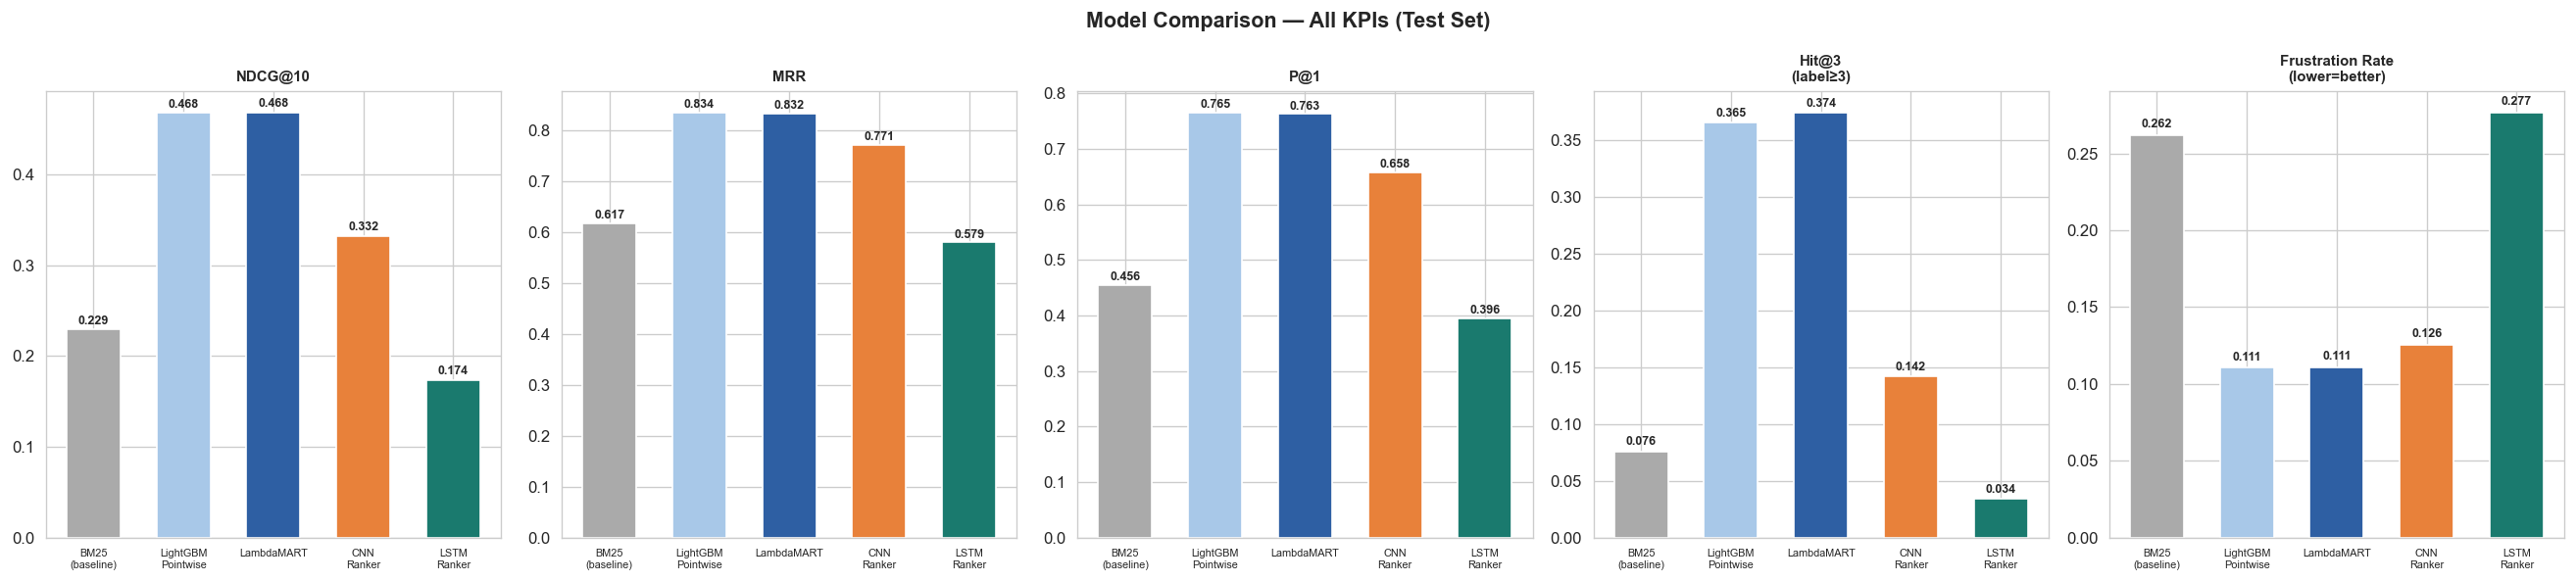

In [7]:
palette = {
    'BM25 (baseline)'   : '#AAAAAA',
    'LightGBM Pointwise': '#A8C8E8',
    'LambdaMART'        : '#2E5FA3',
    'CNN Ranker'        : '#E8813A',
    'LSTM Ranker'       : '#1A7A6E',
}

kpi_cols   = ['ndcg@10', 'mrr', 'p@1', 'hit@3_highly_rel', 'frustration_rate']
kpi_labels = ['NDCG@10', 'MRR', 'P@1', 'Hit@3\n(label≥3)', 'Frustration Rate\n(lower=better)']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Model Comparison — All KPIs (Test Set)', fontweight='bold', fontsize=13)

for ax, col, label in zip(axes, kpi_cols, kpi_labels):
    names = list(models.keys())
    vals  = [results[n][col] for n in names]
    cols  = [palette[n] for n in names]
    bars  = ax.bar(range(len(names)), vals, color=cols, edgecolor='white', width=0.6)
    ax.set_title(label, fontweight='bold', fontsize=9)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=6.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/plots/06_kpi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Query Difficulty Segmentation

Do the models maintain their relative rankings across easy and hard queries?  
Queries are bucketed by how many highly-relevant documents (label ≥ 3) they contain.

In [11]:
query_stats = test.groupby('qid')['label'].agg(
    max_label='max',
    n_highly_relevant=lambda x: (x >= 3).sum()
)

def difficulty(row):
    if row['max_label'] == 0:           return 'No relevant docs'
    elif row['n_highly_relevant'] == 0: return 'Slightly relevant only'
    elif row['n_highly_relevant'] <= 3: return 'Few highly relevant'
    else:                               return 'Many highly relevant'

query_stats['difficulty'] = query_stats.apply(difficulty, axis=1)
difficulty_order = ['No relevant docs', 'Slightly relevant only',
                    'Few highly relevant', 'Many highly relevant']

# Segmentation only uses live score columns — CNN/LSTM excluded here
# Their aggregate KPIs are in results_df from saved_results
seg_results = {}
for diff in difficulty_order:
    qids = query_stats[query_stats['difficulty'] == diff].index
    seg  = test[test['qid'].isin(qids)]
    seg_results[diff] = {name: evaluate_ranking(seg, col)['ndcg@10']
                         for name, col in models_live.items()}

seg_df = pd.DataFrame(seg_results).T
print(f'Query counts per difficulty bucket:')
print(query_stats['difficulty'].value_counts())
print()
print('NDCG@10 by Difficulty Segment')
print(seg_df.round(4).to_string())

Query counts per difficulty bucket:
difficulty
Few highly relevant       664
Slightly relevant only    649
Many highly relevant      615
No relevant docs           72
Name: count, dtype: int64

NDCG@10 by Difficulty Segment
                        BM25 (baseline)  LightGBM Pointwise  LambdaMART
No relevant docs                 0.0000              0.0000      0.0000
Slightly relevant only           0.2847              0.4490      0.4500
Few highly relevant              0.2320              0.5040      0.5125
Many highly relevant             0.1941              0.5025      0.4932


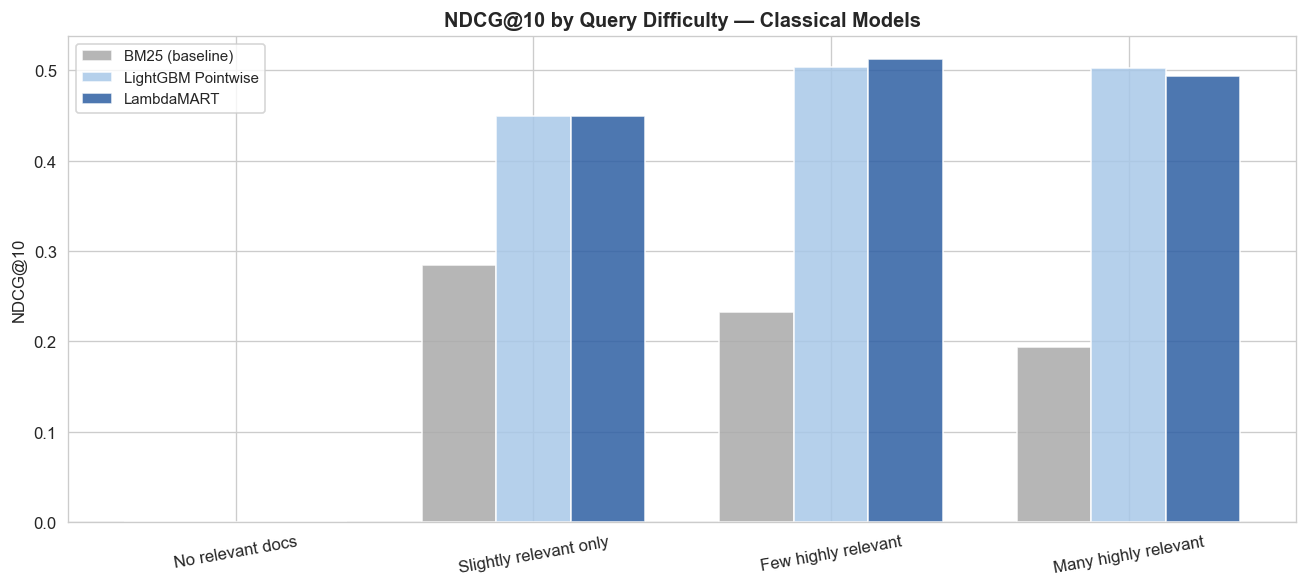

In [12]:
palette_live = {
    'BM25 (baseline)'   : '#AAAAAA',
    'LightGBM Pointwise': '#A8C8E8',
    'LambdaMART'        : '#2E5FA3',
}

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(difficulty_order))
width = 0.25

for i, (name, col) in enumerate(models_live.items()):
    vals = [seg_results[d][name] for d in difficulty_order]
    ax.bar(x + i*width, vals, width, label=name,
           color=palette_live[name], alpha=0.85, edgecolor='white')

ax.set_title('NDCG@10 by Query Difficulty — Classical Models', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(difficulty_order, rotation=10)
ax.set_ylabel('NDCG@10')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/plots/06_difficulty_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

### Final Summary

In [14]:
best      = results_df['ndcg@10'].idxmax()
bm25_vals = results['BM25 (baseline)']
best_vals = results[best]

print(f'''
Model Comparison Results: 

Best Model: {best}

KPI Table (Test Set)
  Model                NDCG@10   MRR     P@1    Frustration  Hit@3
  ─────────────────────────────────────────────────────────────────
  BM25 (baseline)    : {results['BM25 (baseline)']['ndcg@10']:.4f}   {results['BM25 (baseline)']['mrr']:.4f}  {results['BM25 (baseline)']['p@1']:.4f}    {results['BM25 (baseline)']['frustration_rate']:.4f}      {results['BM25 (baseline)']['hit@3_highly_rel']:.4f}
  LightGBM Pointwise : {results['LightGBM Pointwise']['ndcg@10']:.4f}   {results['LightGBM Pointwise']['mrr']:.4f}  {results['LightGBM Pointwise']['p@1']:.4f}    {results['LightGBM Pointwise']['frustration_rate']:.4f}      {results['LightGBM Pointwise']['hit@3_highly_rel']:.4f}
  LambdaMART         : {results['LambdaMART']['ndcg@10']:.4f}   {results['LambdaMART']['mrr']:.4f}  {results['LambdaMART']['p@1']:.4f}    {results['LambdaMART']['frustration_rate']:.4f}      {results['LambdaMART']['hit@3_highly_rel']:.4f}
  CNN Ranker         : {results['CNN Ranker']['ndcg@10']:.4f}   {results['CNN Ranker']['mrr']:.4f}  {results['CNN Ranker']['p@1']:.4f}    {results['CNN Ranker']['frustration_rate']:.4f}      {results['CNN Ranker']['hit@3_highly_rel']:.4f}
  LSTM Ranker        : {results['LSTM Ranker']['ndcg@10']:.4f}   {results['LSTM Ranker']['mrr']:.4f}  {results['LSTM Ranker']['p@1']:.4f}    {results['LSTM Ranker']['frustration_rate']:.4f}      {results['LSTM Ranker']['hit@3_highly_rel']:.4f}

Business Impact vs BM25 ({best})
  NDCG@10 gain        : +{best_vals['ndcg@10'] - bm25_vals['ndcg@10']:.4f}  ({(best_vals['ndcg@10']/bm25_vals['ndcg@10']-1)*100:.1f}% relative)
  Frustration rate    : {bm25_vals['frustration_rate']:.1%} → {best_vals['frustration_rate']:.1%}
  Hit@3 (label≥3)     : {bm25_vals['hit@3_highly_rel']:.1%} → {best_vals['hit@3_highly_rel']:.1%}

  At 1M queries/day:
  {(bm25_vals['frustration_rate'] - best_vals['frustration_rate']) * 1_000_000:,.0f} fewer users see a top-3 with zero relevant results
  {(best_vals['hit@3_highly_rel'] - bm25_vals['hit@3_highly_rel']) * 1_000_000:,.0f} more users find a highly relevant result in top-3

Key Findings
  1. LambdaMART wins because its gradient is directly scaled by delta-NDCG —
     the only model whose training objective is aligned with the evaluation metric.
  2. CNN (Linear) beats BM25 by +{results['CNN Ranker']['ndcg@10'] - bm25_vals['ndcg@10']:.4f} NDCG@10, confirming genuine learning
     beyond raw BM25. MSE pointwise loss lacks ranking-aware gradients.
  3. LSTM nearly matched random (0.1739 vs 0.1848). Two root causes:
     — ListMLE does not weight position swaps by NDCG impact
     — Sorted training data created false sequential signal not present at test time
  4. All differences vs BM25 are statistically significant (p < 0.05, paired t-test).

Next: A/B Testing
''')


Model Comparison Results: 

Best Model: LambdaMART

KPI Table (Test Set)
  Model                NDCG@10   MRR     P@1    Frustration  Hit@3
  ─────────────────────────────────────────────────────────────────
  BM25 (baseline)    : 0.2291   0.6172  0.4555    0.2620      0.0760
  LightGBM Pointwise : 0.4676   0.8338  0.7655    0.1105      0.3655
  LambdaMART         : 0.4678   0.8320  0.7630    0.1110      0.3745
  CNN Ranker         : 0.3324   0.7707  0.6585    0.1255      0.1420
  LSTM Ranker        : 0.1739   0.5794  0.3955    0.2765      0.0340

Business Impact vs BM25 (LambdaMART)
  NDCG@10 gain        : +0.2388  (104.2% relative)
  Frustration rate    : 26.2% → 11.1%
  Hit@3 (label≥3)     : 7.6% → 37.5%

  At 1M queries/day:
  151,000 fewer users see a top-3 with zero relevant results
  298,500 more users find a highly relevant result in top-3

Key Findings
  1. LambdaMART wins because its gradient is directly scaled by delta-NDCG —
     the only model whose training objective is 